---
# 🛰️​🗺️​ 1° rete: Autoencoder per super-resolution sul dataset EuroSAT
---
Studentessa: Beatrice Laureti

Matricola: 165255


---

1.   **SET UP:** importo librerie


2.   **VISIONE GLOBALE DEL DATASET:** visualizzazione immagini, istogramma di frequenza classi

3. **ARCHITETTURA AUTOENCODER:**

  - Input: 32x32

  - Encoder: conv2d 3 $\to$ 32 $\to$ 64 $\to$ 128

  - Decoder: upsample bilineare, (conv2d 128 $\to$ 64 $\to$ 32 $\to$ 3), sigmoide

  - Output: 64x64

4. **TRAIN:** split dataset, L1 loss, Adam, andamento train e validation (loss, SSIM, PSNR)

5. **RISULTATI OTTENUTI:** valutazione metriche su test set per classe, visualizzazione immagini (originale, sfocata, ricostruita, heatmap)






##⚙️ SET UP

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 31.5 MB/s eta 0:00:00


In [ ]:
# IMPORTO LIBRERIE

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import time
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import collections # per creazione istogramma

from torch.utils.data import random_split
from torch.utils.data import DataLoader
from torchmetrics.image import StructuralSimilarityIndexMeasure
from torchmetrics.image.psnr import PeakSignalNoiseRatio



## 🗂️ VISIONE GLOBALE DEL DATASET

### Definizione delle trasformazioni, caricamento dataset e creazione dataloader

In [ ]:
# DEFINIZIONE DELLE TRASFORMAZIONI

low_res_size = 32
high_res_size = 64


# Porto le immagini originali alla stessa dimensione 64x64 e le converto in Tensor
transform = transforms.Compose([
    transforms.Resize((high_res_size, high_res_size)), # Per sicurezza, EuroSAT è già 64x64
    transforms.ToTensor(), # Converte immagine PIL (0-255) a Tensor (0.0-1.0)
])

# Funzione per sporcare l'immagine
def make_low_res(img_tensor):
    # Rimpicciolisce
    down = transforms.Resize((low_res_size, low_res_size), interpolation=transforms.InterpolationMode.BICUBIC)
    img_lr= down(img_tensor)
    # Riporta i valori nel range [0, 1] eliminando l'overshooting
    return torch.clamp(img_lr, 0, 1)


# CARICAMENTO DEL DATASET
print("Download e caricamento del dataset.")
eurosat_dataset = torchvision.datasets.EuroSAT(
    root='./data', # indica dove salvare i dati
    download=True, # scarica il file se non è presente
    transform=transform # applico le transformazioni alle immagini
)

# CREAZIONE DEL DATALOADER
# Il DataLoader serve per prendere le immagini a batch invece di caricarle tutte insieme in memoria
batch_size = 16
train_loader = DataLoader(
    eurosat_dataset,
    batch_size=batch_size,
    shuffle=True  # Mescola le immagini ogni volta
)



Download e caricamento del dataset.


100%|██████████| 94.3M/94.3M [00:01<00:00, 72.3MB/s]


### Visualizzazione immagini originali e esempio di immagine originale e sfocata

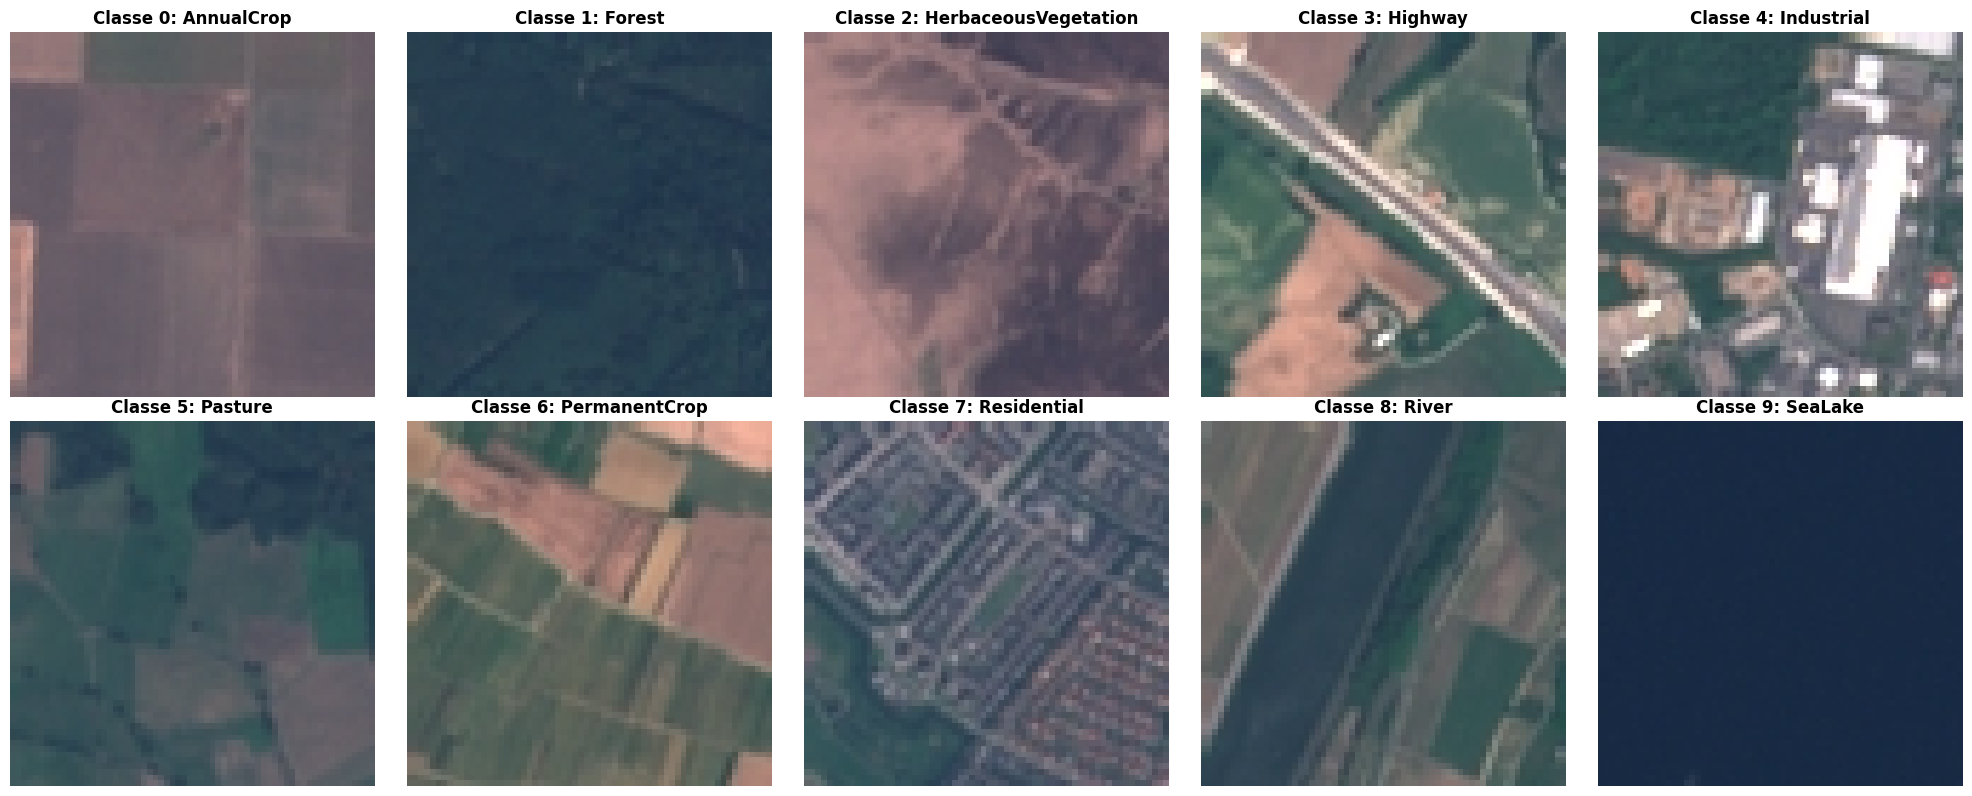

In [ ]:
def show_one_per_class(dataset):
    class_names = dataset.classes
    found_classes = {}

    # Cerchiamo un'immagine per ogni classe nel dataset
    for i in range(len(dataset)):
        img, label = dataset[i]
        if label not in found_classes:
            found_classes[label] = img
        if len(found_classes) == 10:
            break

    # Configurazione grafico 2 righe x 5 colonne
    plt.figure(figsize=(20, 8))

    for i in range(10):
        plt.subplot(2, 5, i + 1)

        # Conversione da Tensor [C, H, W] a Numpy [H, W, C]
        img = found_classes[i].numpy().transpose((1, 2, 0))

        # Clip per sicurezza se i dati non sono in [0,1]
        img = np.clip(img, 0, 1)

        plt.imshow(img)
        plt.title(f"Classe {i}: {class_names[i]}", fontsize=12, fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Esecuzione della funzione sul dataset originale
show_one_per_class(eurosat_dataset)


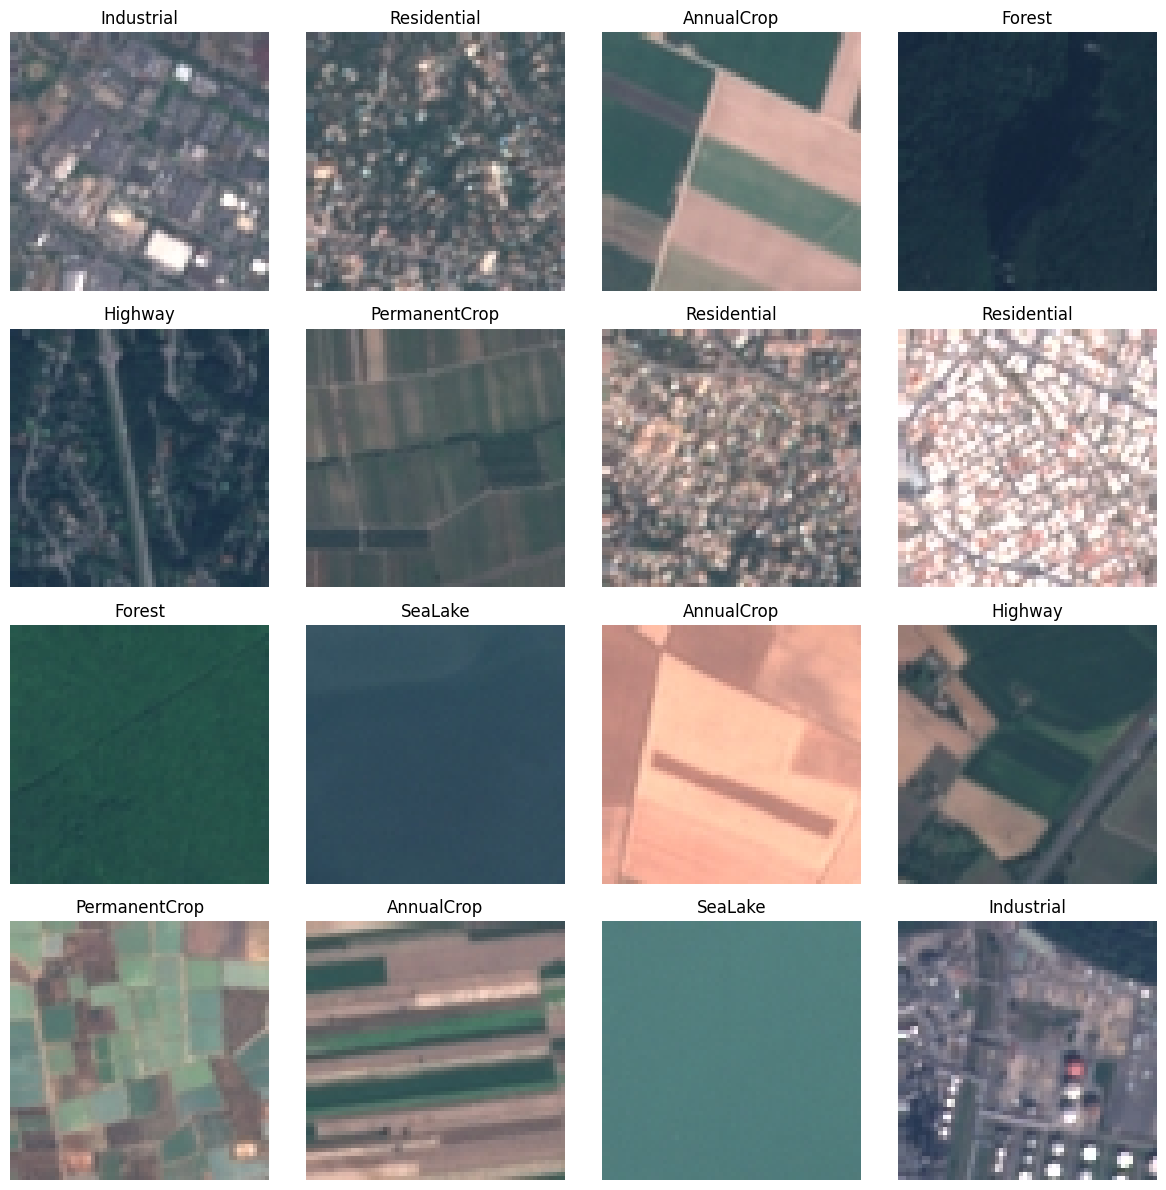

Formato di un batch di immagini: torch.Size([16, 3, 64, 64]) -> [Batch size, Canali RGB, Altezza, Larghezza]


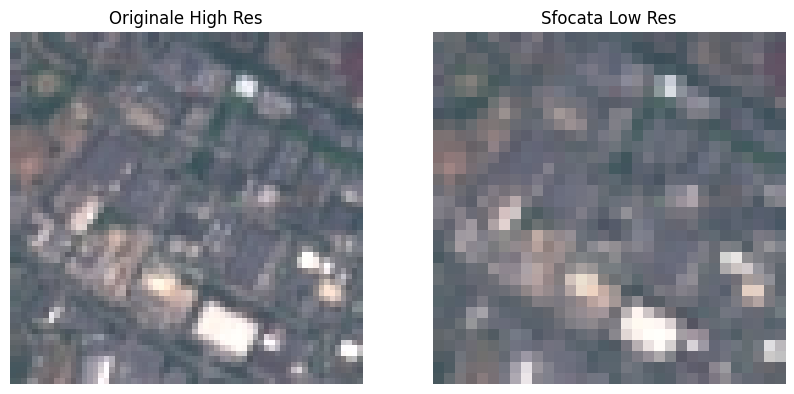

In [ ]:
def show_images(images, labels):
    # EuroSAT ha 10 classi, visualizzo i nomi corrispondenti agli indici
    class_names = eurosat_dataset.classes

    plt.figure(figsize=(12, 12))
    num_to_show = min(16, len(images))

    for i in range(num_to_show):
        plt.subplot(4, 4, i + 1)

        # Prendo solo le prime 16 immagini dal batch
        # PyTorch carica le immagini come [Canali, Altezza, Larghezza]
        # Matplotlib vuole [Altezza, Larghezza, Canali]
        img = images[i].numpy().transpose((1, 2, 0)) # sistema l'ordine

        plt.imshow(img)
        plt.title(class_names[labels[i]]) # mostro il nome della categoria
        plt.axis('off')

    plt.tight_layout()
    plt.show()


# PRENDO UN BATCH DI IMMAGINI E LO VISUALIZZO
dataiter = iter(train_loader) # Prendo un batch
images, labels = next(dataiter) # prendo il primo pacchetto del loader

# Visualizzo l'immagine e la label
show_images(images, labels)

print(f"Formato di un batch di immagini: {images.shape} -> [Batch size, Canali RGB, Altezza, Larghezza]")


# VISUALIZZAZIONE IMMAGINE ORIGINALE E SFOCATA

# Creazione della versione sfocata
low_res_images = make_low_res(images)

# Visualizzazione del confronto
plt.figure(figsize=(10, 5))

# Immagine Nitida (Target per l'AE)
plt.subplot(1, 2, 1)
plt.imshow(images[0].permute(1, 2, 0))
plt.title("Originale High Res")
plt.axis('off')

# Immagine Sfocata (Input per l'AE)
lr_vis = F.interpolate(
    low_res_images,
    size=(high_res_size, high_res_size),
    mode='nearest'
)

plt.subplot(1, 2, 2)
plt.imshow(lr_vis[0].permute(1, 2, 0))
plt.title("Sfocata Low Res") # upsampled per visualizzazione
plt.axis('off')

plt.show()

### Creazione istogramma di frequenza delle classi

Numero totale di immagini nel dataset: 27000

Numero di immagini per classe:
- AnnualCrop: 3000
- Forest: 3000
- HerbaceousVegetation: 3000
- Highway: 2500
- Industrial: 2500
- Pasture: 2000
- PermanentCrop: 2500
- Residential: 3000
- River: 2500
- SeaLake: 3000


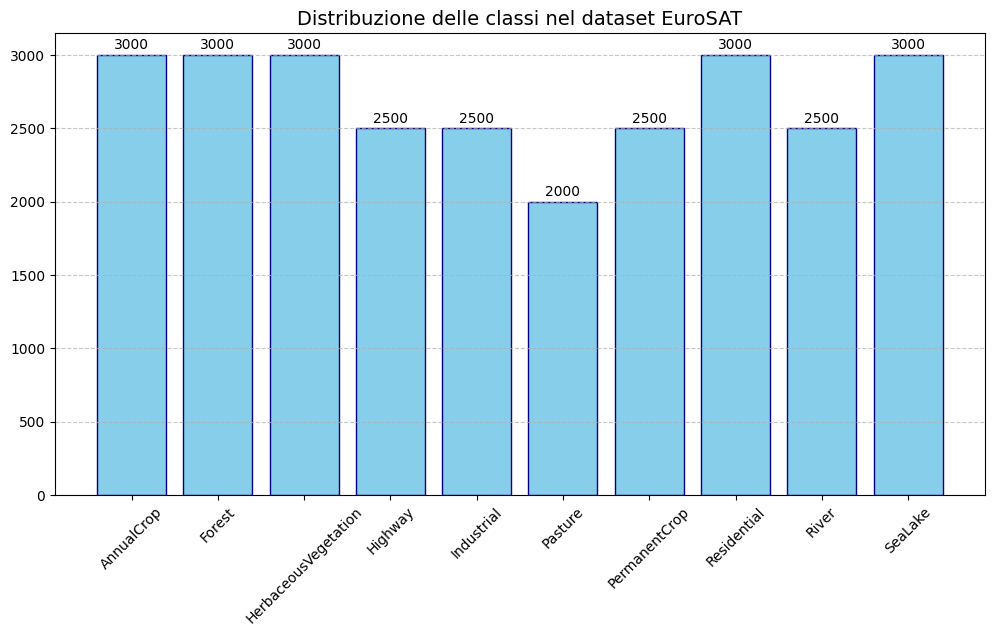

In [ ]:
# Conteggio immagini totali
total_images = len(eurosat_dataset)
print(f"Numero totale di immagini nel dataset: {total_images}")

# Estrazione dei target e i nomi delle classi
targets = eurosat_dataset.targets
class_names = eurosat_dataset.classes

# Conteggio quante volte appare ogni indice di classe
counter = collections.Counter(targets)

# Creazione delle due liste per il grafico: nomi delle classi e rispettivi conteggi
names = [class_names[i] for i in range(len(class_names))]
counts = [counter[i] for i in range(len(class_names))]

print("\nNumero di immagini per classe:")
for name, count in zip(names, counts):
    print(f"- {name}: {count}")

# Creazione istogramma delle ferquenze
plt.figure(figsize=(12, 6))
bars = plt.bar(names, counts, color='skyblue', edgecolor='navy')

# Numeri sopra le barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 20, yval, ha='center', va='bottom')

plt.title('Distribuzione delle classi nel dataset EuroSAT', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()



## 🌐 ARCHITETTURA AUTOENCODER


In [ ]:
class SuperResAE(nn.Module):
    def __init__(self):
        super(SuperResAE, self).__init__()

        # ENCODER
        # Lavora sull'input originale (32x32)
        self.enc1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.enc2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.enc3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.relu = nn.ReLU()

        # DECODER (con Upsampling)
        # Porto la risoluzione da 32x32 a 64x64
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)

        self.dec1 = nn.Conv2d(128, 64, kernel_size=3, padding=1)
        self.dec2 = nn.Conv2d(64, 32, kernel_size=3, padding=1)
        self.dec3 = nn.Conv2d(32, 3, kernel_size=3, padding=1)

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Encoder (estrazione feature a bassa risoluzione)
        out = self.relu(self.enc1(x))
        out = self.relu(self.enc2(out))
        out = self.relu(self.enc3(out))

        # Decoder e Upsampling (ricostruzione spaziale)
        out = self.upsample(out)
        out = self.relu(self.dec1(out))
        out = self.relu(self.dec2(out))

        # Output finale
        out = self.dec3(out)

        return self.sigmoid(out)

# Creazione dell'istanza del modello
model = SuperResAE()


# Spostamento del modello su GPU se disponibile
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


SuperResAE(
  (enc1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (upsample): Upsample(scale_factor=2.0, mode='bilinear')
  (dec1): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dec2): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dec3): Conv2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (sigmoid): Sigmoid()
)

## 🧠 TRAIN

### Split del dataset

In [ ]:
# Calcolo delle dimensioni (70% training, 20% validation, 10% test)
train_size = int(0.7 * total_images)
val_size = int(0.2 * total_images)
test_size = total_images - train_size - val_size

# Split casuale
train_set, val_set, test_set = random_split(
    eurosat_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Creazione dei nuovi DataLoader splittati
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

print(f"Suddivisione immagini dataset:")
print(f" - Training set: {len(train_set)}")
print(f" - Validation set: {len(val_set)}")
print(f" - Test set: {len(test_set)}")

Suddivisione immagini dataset:
 - Training set: 18900
 - Validation set: 5400
 - Test set: 2700


### Training loop

Modello configurato e pronto su: cuda
Inizio addestramento con monitoraggio metriche.
Epoca [1/40] | Train Loss: 0.023622 | Val Loss: 0.015143 | Train SSIM: 0.8568 | Val SSIM: 0.9184 | Train PSNR: 29.78 dB | Val PSNR: 32.63 dB
Epoca [2/40] | Train Loss: 0.014612 | Val Loss: 0.016381 | Train SSIM: 0.9252 | Val SSIM: 0.9290 | Train PSNR: 32.84 dB | Val PSNR: 32.63 dB
Epoca [3/40] | Train Loss: 0.013595 | Val Loss: 0.014051 | Train SSIM: 0.9313 | Val SSIM: 0.9321 | Train PSNR: 33.34 dB | Val PSNR: 33.45 dB
Epoca [4/40] | Train Loss: 0.013310 | Val Loss: 0.013604 | Train SSIM: 0.9338 | Val SSIM: 0.9363 | Train PSNR: 33.53 dB | Val PSNR: 33.67 dB
Epoca [5/40] | Train Loss: 0.013062 | Val Loss: 0.012452 | Train SSIM: 0.9356 | Val SSIM: 0.9380 | Train PSNR: 33.65 dB | Val PSNR: 33.90 dB
Epoca [6/40] | Train Loss: 0.012527 | Val Loss: 0.012074 | Train SSIM: 0.9373 | Val SSIM: 0.9391 | Train PSNR: 33.91 dB | Val PSNR: 34.24 dB
Epoca [7/40] | Train Loss: 0.012455 | Val Loss: 0.013014 | Train SSI

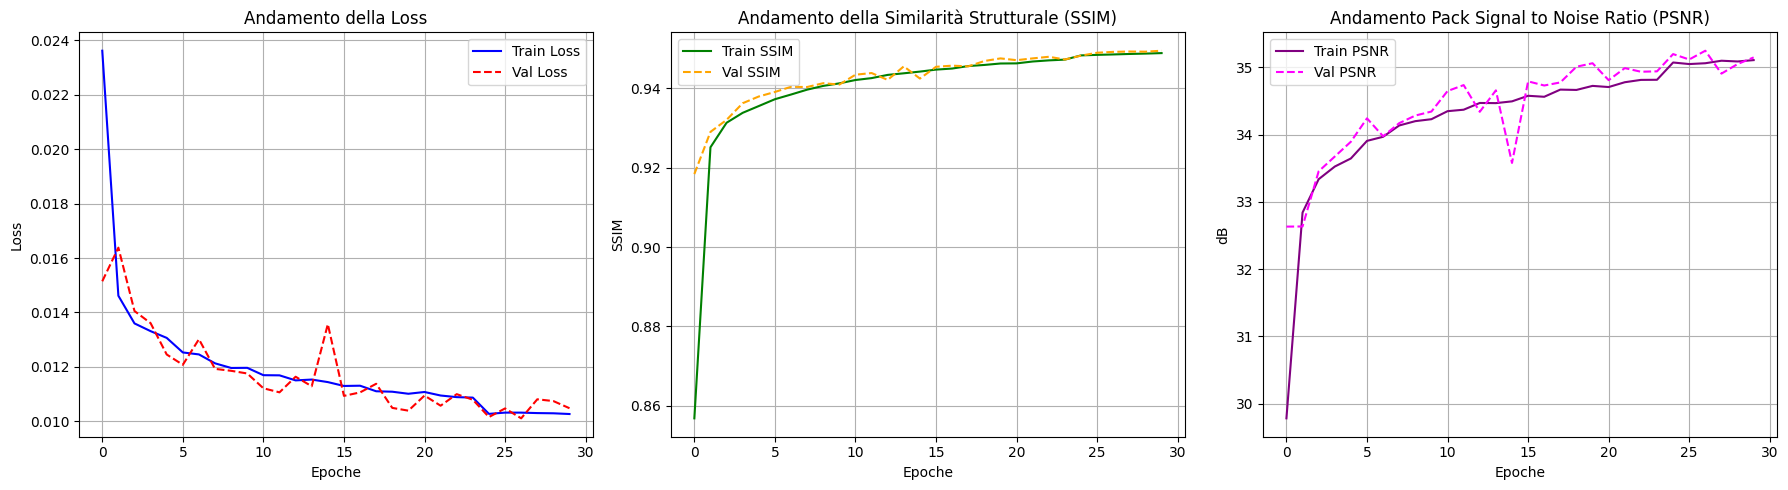

In [ ]:
# DEFINIZIONE LOSS (L1) E OTTIMIZZATORE (ADAM)

# Definizione della funzione di perdita (loss)
criterion = nn.L1Loss()

# Definizione dell'ottimizzatore
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5) # scheduler per learning rate


print(f"Modello configurato e pronto su: {device}")


# Inizializzazione della metrica SSIM e PSNR (specificando il range dei dati 0-1)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)

num_epochs = 40
history = {
    'train_loss': [], 'val_loss': [],
    'train_ssim': [], 'val_ssim': [],
    'train_psnr': [], 'val_psnr': []
}

print("Inizio addestramento con monitoraggio metriche.")



# Inizializzazione parametri early stopping
patience = 5 # epoche senza miglioramento
min_delta = 1e-4 # miglioramento minimo
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None


# For su epoche
for epoch in range(num_epochs):
    start_time = time.time()


    # TRAINING
    model.train()
    running_train_loss = 0.0
    running_train_ssim = 0.0
    running_train_psnr = 0.0

    # For su batch
    for images, _ in train_loader:
        images_hr = images.to(device) # immagini ad alta risoluzione
        images_lr = make_low_res(images).to(device) # creazione immagini bassa risoluzione

        optimizer.zero_grad() # cancello calcoli gradiente batch precedente
        outputs = model(images_lr) # diamo al modello l'immagine a bassa risoluzione
        loss = criterion(outputs, images_hr) # calcolo loss tra immagine originale e la ricostruita

        # Aggiorno pesi
        loss.backward() # passo backward
        optimizer.step() # ottimizzatore

        # Calcolo somma val loss e val ssim sui batch
        running_train_loss += loss.item() * images_hr.size(0)  # moltiplica la loss media del batch per il numero di immagini nel batch attuale (ultimo batch può essere diverso)
        running_train_ssim += ssim_metric(outputs, images_hr).item() * images_hr.size(0)
        running_train_psnr += psnr_metric(outputs, images_hr).item() * images_hr.size(0)

    # Calcolo train loss e train ssim
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_ssim = running_train_ssim / len(train_loader.dataset)
    epoch_train_psnr = running_train_psnr / len(train_loader.dataset)


    # VALIDATION
    model.eval()
    running_val_loss = 0.0
    running_val_ssim = 0.0
    running_val_psnr = 0.0

    with torch.no_grad():
        for images, _ in val_loader:
            images_hr = images.to(device)
            images_lr = make_low_res(images).to(device)

            outputs = model(images_lr)
            loss = criterion(outputs, images_hr)

            # Calcolo somma val loss e val ssim
            running_val_loss += loss.item() * images_hr.size(0)
            running_val_ssim += ssim_metric(outputs, images_hr).item() * images_hr.size(0)
            running_val_psnr += psnr_metric(outputs, images_hr).item() * images_hr.size(0)

    # Calcolo val loss e val ssim
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_ssim = running_val_ssim / len(val_loader.dataset)
    epoch_val_psnr = running_val_psnr / len(val_loader.dataset)


    scheduler.step(epoch_val_loss)

    # Salvataggio storia
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_ssim'].append(epoch_train_ssim)
    history['val_ssim'].append(epoch_val_ssim)
    history['train_psnr'].append(epoch_train_psnr)
    history['val_psnr'].append(epoch_val_psnr)

    print(f"Epoca [{epoch+1}/{num_epochs}] | Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f} | Train SSIM: {epoch_train_ssim:.4f} | Val SSIM: {epoch_val_ssim:.4f} | Train PSNR: {epoch_train_psnr:.2f} dB | Val PSNR: {epoch_val_psnr:.2f} dB")


    # Early stopping
    if epoch_val_loss < best_val_loss - min_delta:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        best_model_state = model.state_dict()
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping attivato all'epoca {epoch+1}")
        break


if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Miglior modello (val_loss minima) ripristinato.")


# GENERAZIONE GRAFICI ANDAMENTO TRAIN E VAL LOSS SSIM PSNR
plt.figure(figsize=(18, 5))

# Grafico Loss
plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue')
plt.plot(history['val_loss'], label='Val Loss', color='red', linestyle='--')
plt.title('Andamento della Loss')
plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Grafico SSIM
plt.subplot(1, 3, 2)
plt.plot(history['train_ssim'], label='Train SSIM', color='green')
plt.plot(history['val_ssim'], label='Val SSIM', color='orange', linestyle='--')
plt.title('Andamento della Similarità Strutturale (SSIM)')
plt.xlabel('Epoche')
plt.ylabel('SSIM')
plt.legend()
plt.grid(True)

# Grafico 3: PSNR
plt.subplot(1, 3, 3)
plt.plot(history['train_psnr'], label='Train PSNR', color='purple')
plt.plot(history['val_psnr'], label='Val PSNR', color='magenta', linestyle='--')
plt.title('Andamento Pack Signal to Noise Ratio (PSNR)')
plt.xlabel('Epoche')
plt.ylabel('dB')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 📉 RISULTATI OTTENUTI

### Valutazione metriche sul test set (globali e per classe)

In [ ]:
# Mettiamo il modello in eval e inizializziamo le metriche
model.eval()
class_names = eurosat_dataset.classes

# Dizionari per accumulare i risultati per ogni classe
# Struttura: {indice_classe: [somma_loss, somma_ssim, somma_psnr, conteggio_immagini]}
class_metrics = {i: [0.0, 0.0, 0.0, 0] for i in range(len(class_names))}

total_test_loss = 0.0
total_test_ssim = 0.0
total_test_psnr = 0.0
num_test_samples = 0

with torch.no_grad():
    for images, labels in test_loader:
        # Caricamento delle immagini e creazioni delle versioni a bassa risoluzione
        images_hr = images.to(device)
        images_lr = make_low_res(images).to(device)

        outputs = model(images_lr)

        # Calcolo metriche batch
        batch_loss = criterion(outputs, images_hr)
        batch_ssim = ssim_metric(outputs, images_hr)
        batch_psnr = psnr_metric(outputs, images_hr)

        # Accumulo globale
        bs = images_hr.size(0)
        total_test_loss += batch_loss.item() * bs
        total_test_ssim += batch_ssim.item() * bs
        total_test_psnr += batch_psnr.item() * bs
        num_test_samples += bs

        # Accumulo per classe (itero sugli elementi del batch)
        for i in range(bs):
            img_hr = images_hr[i].unsqueeze(0)
            img_out = outputs[i].unsqueeze(0)
            label = labels[i].item()

            l = criterion(img_out, img_hr).item()
            s = ssim_metric(img_out, img_hr).item()
            p = psnr_metric(img_out, img_hr).item()

            class_metrics[label][0] += l
            class_metrics[label][1] += s
            class_metrics[label][2] += p
            class_metrics[label][3] += 1

# Calcolo medie globali etst set
final_loss = total_test_loss / num_test_samples
final_ssim = total_test_ssim / num_test_samples
final_psnr = total_test_psnr / num_test_samples


# Stampa medie globali test set
print("\n" + "="*50)
print("RISULTATI GLOBALI TEST SET")
print(f"Loss Media: {final_loss:.6f}")
print(f"SSIM Medio: {final_ssim:.4f}")
print(f"PSNR Medio: {final_psnr:.2f} dB")
print("="*50)


# Tabella risultati per classe
results_data = []
for i in range(len(class_names)):
    count = class_metrics[i][3]
    if count > 0:
        avg_l = class_metrics[i][0] / count
        avg_s = class_metrics[i][1] / count
        avg_p = class_metrics[i][2] / count

        results_data.append([class_names[i], count, avg_l, avg_s, avg_p])

df_results = pd.DataFrame(results_data, columns=['Classe', 'Campioni', 'Loss', 'SSIM', 'PSNR'])

# Ordiniamo in ordine crescente di SSIM
df_results_sorted = df_results.sort_values(by='SSIM', ascending=True).reset_index(drop=True)

df_results_sorted['Loss'] = df_results_sorted['Loss'].map(lambda x: f"{x:.6f}")
df_results_sorted['SSIM'] = df_results_sorted['SSIM'].map(lambda x: f"{x:.4f}")
df_results_sorted['PSNR'] = df_results_sorted['PSNR'].map(lambda x: f"{x:.2f} dB")

print("\nDETTAGLIO PER CLASSE (ordinato per SSIM crescente):")
print(df_results_sorted)



RISULTATI GLOBALI TEST SET
Loss Media: 0.010691
SSIM Medio: 0.9478
PSNR Medio: 34.97 dB

DETTAGLIO PER CLASSE (ordinato per SSIM crescente):
                 Classe  Campioni      Loss    SSIM      PSNR
0           Residential       314  0.022730  0.8637  30.70 dB
1            Industrial       257  0.022125  0.9205  29.94 dB
2         PermanentCrop       254  0.011804  0.9410  36.19 dB
3  HerbaceousVegetation       302  0.010253  0.9428  38.31 dB
4               Highway       269  0.010324  0.9525  37.02 dB
5                 River       245  0.007772  0.9645  39.12 dB
6                Forest       297  0.005235  0.9677  43.59 dB
7               Pasture       187  0.005727  0.9704  42.05 dB
8            AnnualCrop       300  0.005836  0.9776  42.18 dB
9               SeaLake       275  0.003235  0.9923  47.49 dB


### Visualizzazione di un batch del test set (Originale, Sfocata, Ricostruita, Heatmap)

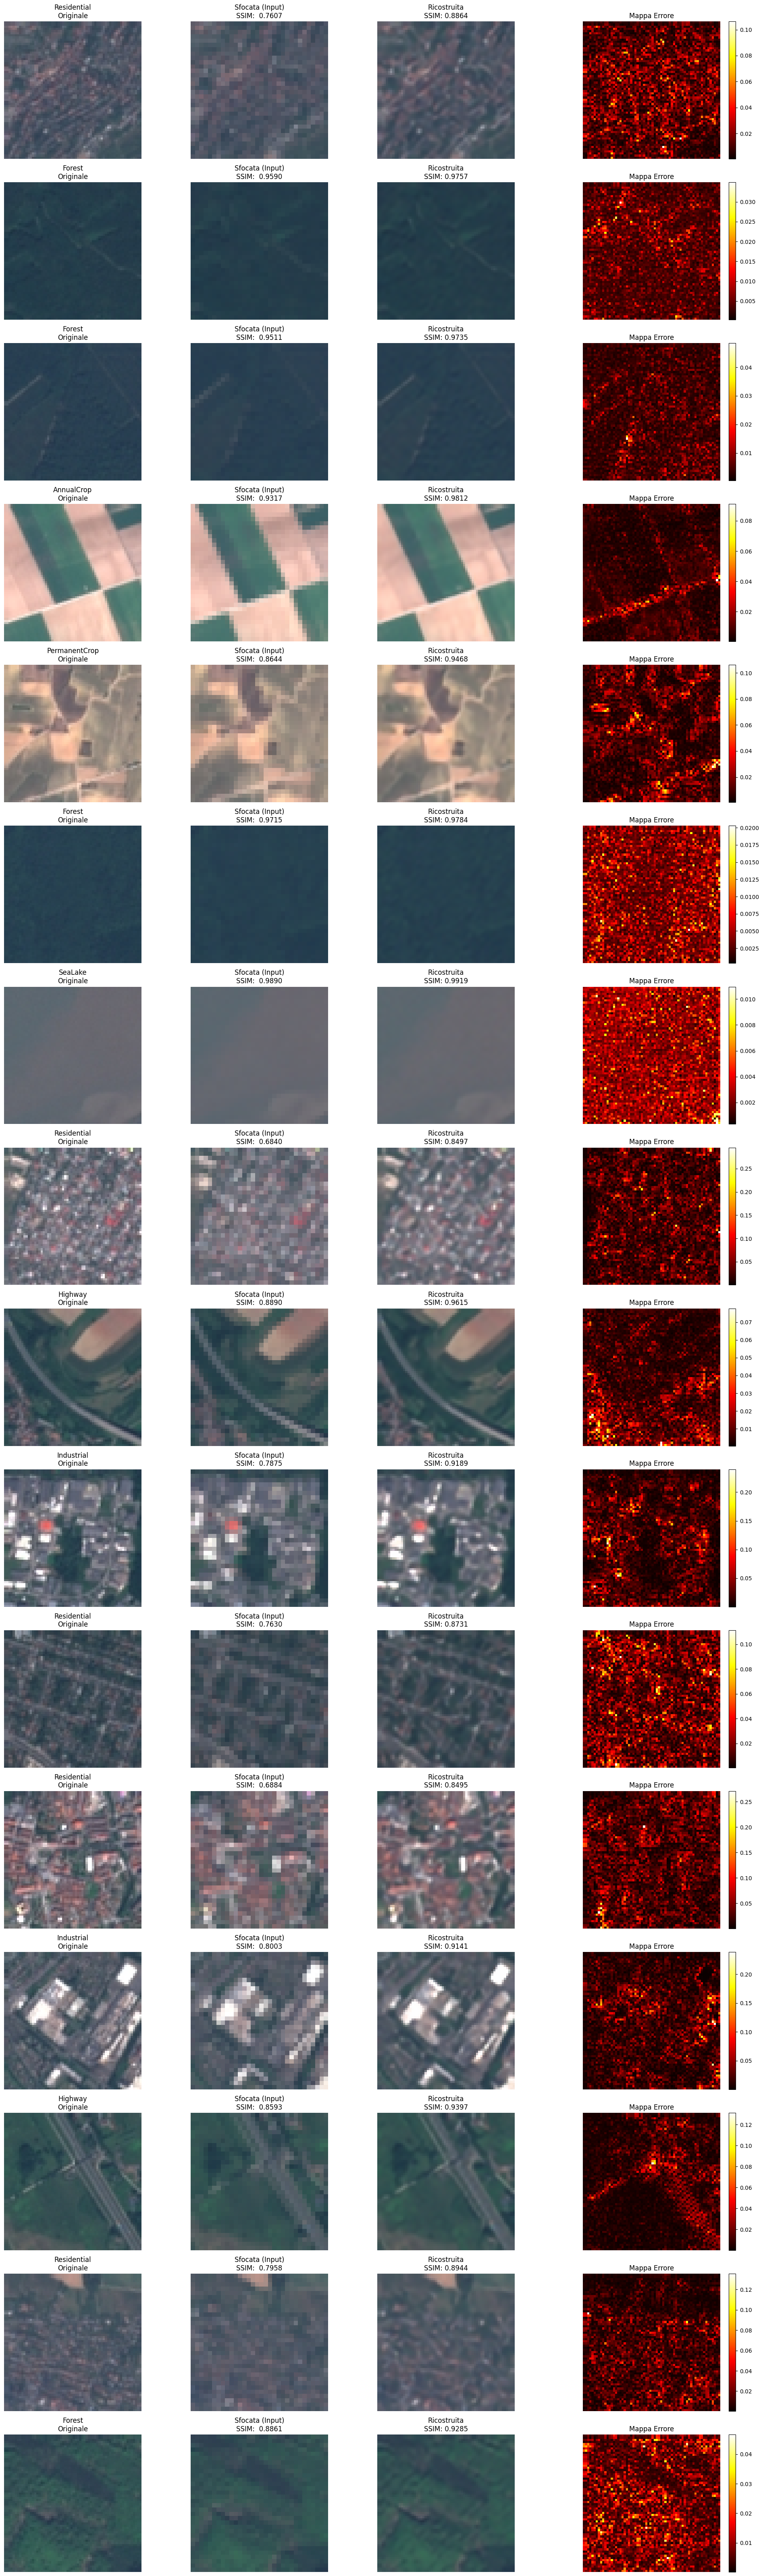

In [ ]:
# Prendiamo un batch del test set per la visualizzazione dei risultati
dataiter = iter(test_loader)
images_hr, labels = next(dataiter)
images_hr = images_hr.to(device)
images_lr = make_low_res(images_hr).to(device)

with torch.no_grad():
    reconstructed = model(images_lr)

images_hr = images_hr.cpu()
images_lr = images_lr.cpu()
reconstructed = reconstructed.cpu()

# VISUALIZZAZIONE DI UN BATCH DEL TEST SET (Originale, Sfocata, Ricostruita, Heatmap)

batch_size_to_show = batch_size # quantità immagini visualizzate
plt.figure(figsize=(20, 4 * batch_size_to_show))

for i in range(batch_size_to_show):
    # Calcolo SSIM singolo per titolo
    # Per la ricostruita
    ssim_single = ssim_metric(reconstructed[i].unsqueeze(0), images_hr[i].unsqueeze(0)).item()
    # Per la sfocata
    img_lr_up = F.interpolate(images_lr[i].unsqueeze(0), size=(64, 64), mode='bilinear', align_corners=False) # per confrontarla devo riportarla a 64x64
    ssim_blur = ssim_metric(img_lr_up, images_hr[i].unsqueeze(0)).item()

    label_name = class_names[labels[i].item()]


    # Originale
    plt.subplot(batch_size_to_show, 4, i*4 + 1)
    plt.imshow(images_hr[i].permute(1, 2, 0))
    plt.title(f"{label_name}\nOriginale")
    plt.axis('off')

    # Sfocata
    plt.subplot(batch_size_to_show, 4, i*4 + 2)
    plt.imshow(images_lr[i].permute(1, 2, 0))
    plt.title(f"Sfocata (Input)\nSSIM:  {ssim_blur:.4f}")
    plt.axis('off')

    # Ricostruita
    plt.subplot(batch_size_to_show, 4, i*4 + 3)
    plt.imshow(reconstructed[i].permute(1, 2, 0))
    plt.title(f"Ricostruita\nSSIM: {ssim_single:.4f}")
    plt.axis('off')

    # Heatmap (errore assoluto pixel wise mediato sui 3 canali)
    plt.subplot(batch_size_to_show, 4, i*4 + 4)
    diff = torch.abs(images_hr[i] - reconstructed[i]).mean(dim=0)
    plt.imshow(diff, cmap='hot')
    plt.title("Mappa Errore")
    plt.axis('off')
    plt.colorbar(fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
